# Side-Looking SAR Validation: NISAR

This notebook validates TAT-C's representation of a side-looking synthetic aperture radar (SAR) against the [NASA-ISRO Synthetic Aperture Radar (NISAR)](https://nisar.jpl.nasa.gov/) mission. NISAR's L-band radar (L-SAR) looks to the left of its flight direction and images a swath about 240 km wide at incidence angles of about 33 to 47 deg.

In TAT-C, a side-looking instrument is a `PointedInstrument` whose view is rotated from nadir by a roll angle (positive to the left of the direction of motion), with a cross-track field of view spanning the swath. TAT-C rotates the view rigidly and, by default, orients it relative to the Earth-fixed velocity (`VelocityFrame.EARTH_FIXED`). SAR images are formed in *zero-Doppler* geometry: each image line contains the targets at the closest approach to the radar, which lie in the plane perpendicular to the Earth-fixed velocity, whatever the spacecraft's attitude. TAT-C's default frame should therefore match a SAR's imaging geometry, as the companion notebooks on NOAA-20 imagers ([ATMS](ValidateImagerATMS.ipynb), [VIIRS](ValidateImagerVIIRS.ipynb)) found the inertial frame matches an instrument that scans without yaw steering.

The comparison asks five questions:

1. **Orbit.** Does TAT-C's propagation of a public two-line element (TLE) set reproduce NISAR's position?
2. **Imaging geometry.** What look direction, look angles, and imaging plane do NISAR's products describe, and which TAT-C roll angle, field of view, and velocity frame reproduce them?
3. **Swath edges.** How closely do the edges of TAT-C's view match the near-range and far-range edges of NISAR's images?
4. **Frame footprints.** Does `compute_ground_track` reproduce the footprints of all the frames NISAR acquired in a day?
5. **Observation times.** Does `collect_observations` predict when NISAR images a point?

## Reference Data

NISAR products are distributed by the NASA Alaska Satellite Facility Distributed Active Archive Center (ASF DAAC). This notebook uses the Level 1 range-Doppler single-look complex (RSLC) product: one HDF5 file per frame (up to about 35 s of data and 760 MB). Besides the image, each file holds metadata:

* `identification`: the granule's look direction, pass direction, zero-Doppler start and end times, and bounding polygon (the image outline at the terrain height, with about 40 vertices);
* `metadata/orbit`: the spacecraft's Earth-fixed position and velocity (from the medium-precision orbit ephemeris) at 10 s intervals;
* `metadata/geolocationGrid`: for a grid of zero-Doppler times and slant ranges, and for a set of heights above the WGS 84 ellipsoid, the geodetic longitude and latitude of the imaged point, and the incidence and elevation (look) angles.

The ASF search API (no account required) lists all RSLC products acquired on 2 October 2026 with their footprints and times. Downloading files requires a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account and the `earthaccess` package; only metadata are downloaded (about 0.1 MB per product, and about 10 MB for each of a sample of products), with HTTP range requests read by `h5py`. The first run takes a few minutes; reduced arrays are cached in a local `data/nisar` directory.

NISAR is modeled with a TLE from [CelesTrak](https://celestrak.org/) whose epoch (3 October 2026, 22:16 UTC) follows the analysis day by up to two days.

In [1]:
import concurrent.futures
import io
import json
import re
from datetime import datetime, timezone
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "nisar"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DAY = datetime(2026, 10, 2, tzinfo=timezone.utc)
SEARCH = "https://api.daac.asf.alaska.edu/services/search/param"
TLE = [
    "1 65053U 25163A   26276.92799516  .00000171  00000+0  64585-4 0  9997",
    "2 65053  98.4055 103.0181 0001222  89.8720 270.2610 14.42503663 62063",
]

PRODUCTS_FILE = DATA_DIR / f"nisar_rslc_{DAY:%Y%m%d}.geojson"
if not PRODUCTS_FILE.exists():
    params = {
        "dataset": "NISAR",
        "processingLevel": "RSLC",
        "start": f"{DAY:%Y-%m-%d}T00:00:00Z",
        "end": f"{DAY:%Y-%m-%d}T23:59:59Z",
        "output": "geojson",
        "maxResults": "5000",
    }
    PRODUCTS_FILE.write_text(requests.get(SEARCH, params=params, timeout=600).text)
catalog = pd.DataFrame(
    [
        {
            "granule": f["properties"]["fileID"],
            "url": f["properties"]["url"],
            "start": pd.Timestamp(f["properties"]["startTime"]),
            "end": pd.Timestamp(f["properties"]["stopTime"]),
            "direction": f["properties"]["flightDirection"].lower(),
            "coverage": f["properties"]["frameCoverage"].lower(),
            # bandwidth and polarization mode codes from the granule name
            "mode": "_".join(f["properties"]["fileID"].split("_")[8:10]),
        }
        for f in json.loads(PRODUCTS_FILE.read_text())["features"]
    ]
)
# products that start on the analysis day
catalog = catalog[catalog.start >= pd.Timestamp(DAY)].sort_values("start", ignore_index=True)
catalog.groupby(["mode", "direction"]).size().unstack(fill_value=0)

direction,ascending,descending
mode,,
0005_NADV,15,18
0005_NASV,166,107
0500_SHNA,4,0
0505_SHSV,0,3
0505_SVSH,39,6
2000_DVNA,0,1
2005_DHDH,132,72
2005_DVDV,0,2
2005_QPDH,2,8


Products are opened remotely and only the needed metadata are read:

* for **every product**, the bounding polygon and the zero-Doppler start and end times; and
* for a **sample** of up to four products of each mode (evenly spaced in time), the orbit and the ground-level (zero height) layer of the geolocation grid, resampled to 41 slant ranges spanning the image.

Times in each product count seconds from an epoch given in its metadata (the start of the day of its first line); they are converted to seconds since 00:00 UTC on the analysis day.

In [2]:
BOUNDS_FILE = DATA_DIR / f"nisar_rslc_bounds_{DAY:%Y%m%d}.csv"
SAMPLE_FILE = DATA_DIR / f"nisar_rslc_metadata_{DAY:%Y%m%d}.npz"
sample = pd.concat(
    [g.iloc[np.unique(np.linspace(0, len(g) - 1, 4).round().astype(int))] for _, g in catalog.groupby("mode")]
).sort_values("start", ignore_index=True)
N_RANGE = 41  # resampled slant ranges across the image

if not (BOUNDS_FILE.exists() and SAMPLE_FILE.exists()):
    import earthaccess

    earthaccess.login()
    session = earthaccess.get_requests_https_session()

    class RemoteFile(io.RawIOBase):
        """Read-only file object that downloads blocks of a remote file with HTTP range requests on demand."""

        def __init__(self, url, block_size=2**16, prefetch=4):
            self.block_size, self.blocks, self.position = block_size, {}, 0
            # follow the Earthdata Login redirects while prefetching the first blocks (file metadata)
            response = self._get(url, 0, prefetch * block_size)
            self.url, self.size = response.url, int(response.headers["Content-Range"].split("/")[1])
            self._store(0, response.content)

        def _get(self, url, start, end):
            for attempt in range(5):
                try:
                    response = session.get(url, headers={"Range": f"bytes={start}-{end - 1}"}, timeout=300)
                    response.raise_for_status()
                    return response
                except requests.RequestException:
                    if attempt == 4:
                        raise

        def _store(self, first, content):
            for i in range(0, len(content), self.block_size):
                self.blocks[first + i // self.block_size] = content[i : i + self.block_size]

        def readable(self):
            return True

        def seekable(self):
            return True

        def tell(self):
            return self.position

        def seek(self, offset, whence=io.SEEK_SET):
            self.position = {io.SEEK_SET: 0, io.SEEK_CUR: self.position, io.SEEK_END: self.size}[whence] + offset
            return self.position

        def readinto(self, buffer):
            n = min(len(buffer), self.size - self.position)
            if n <= 0:
                return 0
            first, last = self.position // self.block_size, (self.position + n - 1) // self.block_size
            missing = [block for block in range(first, last + 1) if block not in self.blocks]
            if missing:
                end = min((missing[-1] + 1) * self.block_size, self.size)
                self._store(missing[0], self._get(self.url, missing[0] * self.block_size, end).content)
            data = b"".join(self.blocks[block] for block in range(first, last + 1))
            offset = self.position - first * self.block_size
            buffer[:n] = data[offset : offset + n]
            self.position += n
            return n

    def seconds_since_day(dataset):
        """Times of a dataset in seconds since the start of the analysis day."""
        epoch = re.search(r"since (\S+)", dataset.attrs["units"].decode()).group(1)
        return dataset[:] + (pd.Timestamp(epoch, tz="UTC") - pd.Timestamp(DAY)).total_seconds()

    def read_bounds(url):
        with h5py.File(RemoteFile(url)) as f:
            identification = f["science/LSAR/identification"]
            return {
                "url": url,
                "polygon": identification["boundingPolygon"][()].decode(),
                "zero_doppler_start": identification["zeroDopplerStartTime"][()].decode(),
                "zero_doppler_end": identification["zeroDopplerEndTime"][()].decode(),
            }

    def read_sample(url):
        with h5py.File(RemoteFile(url, block_size=2**20, prefetch=2)) as f:
            rslc = f["science/LSAR/RSLC"]
            grid = rslc["metadata/geolocationGrid"]
            layer = int(np.argmin(np.abs(grid["heightAboveEllipsoid"][:])))
            grid_range = grid["slantRange"][:]
            frequency = sorted(k for k in rslc["swaths"] if k.startswith("frequency"))[0]
            image_range = rslc[f"swaths/{frequency}/slantRange"][[0, -1]]
            # resample the grid to slant ranges spanning the image, from near to far range
            ranges = np.linspace(image_range[0], image_range[1], N_RANGE)
            resample = lambda x: np.array([np.interp(ranges, grid_range, row) for row in x])
            return {
                "look_direction": f["science/LSAR/identification/lookDirection"][()].decode(),
                "time": seconds_since_day(grid["zeroDopplerTime"]),
                "slant_range": ranges,
                # unwrap longitudes so that interpolation does not cross the antimeridian
                "lon": (resample(np.unwrap(grid["coordinateX"][layer], period=360)) + 180) % 360 - 180,
                "lat": resample(grid["coordinateY"][layer]),
                "incidence": resample(grid["incidenceAngle"][layer]),
                "orbit_time": seconds_since_day(rslc["metadata/orbit/time"]),
                "orbit_position": rslc["metadata/orbit/position"][:],
                "orbit_velocity": rslc["metadata/orbit/velocity"][:],
            }

    with concurrent.futures.ThreadPoolExecutor(16) as pool:
        bounds = pd.DataFrame(pool.map(read_bounds, catalog.url))
        records = list(pool.map(read_sample, sample.url))
    bounds.to_csv(BOUNDS_FILE, index=False)
    # store variable-length records as concatenated arrays with lengths
    np.savez_compressed(
        SAMPLE_FILE,
        look_direction=[r["look_direction"] for r in records],
        n_time=[len(r["time"]) for r in records],
        n_orbit=[len(r["orbit_time"]) for r in records],
        slant_range=np.stack([r["slant_range"] for r in records]),
        **{k: np.concatenate([r[k] for r in records]) for k in ["time", "lon", "lat", "incidence", "orbit_time", "orbit_position", "orbit_velocity"]},
    )

catalog = catalog.merge(pd.read_csv(BOUNDS_FILE), on="url")
cache = dict(np.load(SAMPLE_FILE))
split = lambda key, n: np.split(cache[key], np.cumsum(cache[n])[:-1])
meta = [
    {"look_direction": cache["look_direction"][i], "slant_range": cache["slant_range"][i], **dict(zip(keys, values))}
    for i, values in enumerate(
        zip(
            split("time", "n_time"), split("lon", "n_time"), split("lat", "n_time"), split("incidence", "n_time"),
            split("orbit_time", "n_orbit"), split("orbit_position", "n_orbit"), split("orbit_velocity", "n_orbit"),
        )
    )
    for keys in [("time", "lon", "lat", "incidence", "orbit_time", "orbit_position", "orbit_velocity")]
]
pd.Series(
    {
        "products on the day": len(catalog),
        "products sampled": len(meta),
        "modes sampled": sample["mode"].nunique(),
        "look directions": ", ".join(sorted(set(cache["look_direction"]))),
        "geolocation grid lines": int(cache["n_time"].sum()),
    }
)

products on the day         855
products sampled             44
modes sampled                13
look directions            Left
geolocation grid lines    19201
dtype: object

## Setup

Times in the product metadata count seconds since 00:00 UTC on the analysis day. Helper functions match those of the imager notebooks: Earth-fixed coordinates, horizontal decomposition of offsets along and to the right of a reference direction, and summary statistics.

In [3]:
from datetime import timedelta

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import shapely
import shapely.affinity
import shapely.ops
from pyproj import Geod, Transformer
from shapely.geometry import shape
from shapely.ops import transform as transform_geometry
from skyfield.framelib import itrs

from tatc.analysis import collect_observations, compute_ground_track
from tatc.constants import EARTH_ROTATION_RATE
from tatc.schemas import GeneralPerturbationsOrbit, Point, PointedInstrument, Satellite
from tatc.utils import VelocityFrame, compute_projected_ray_position

GEOD = Geod(ellps="WGS84")
TO_ECEF = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
TO_GEODETIC = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
nisar = Satellite(name="NISAR", orbit=GeneralPerturbationsOrbit.from_tle(TLE))
orbit = nisar.orbit.to_gp_orbit()


def to_utc(seconds):
    return [DAY + timedelta(seconds=float(s)) for s in np.atleast_1d(seconds)]


def ecef(lon, lat, height=0.0):
    """Earth-fixed position (m) of geodetic coordinates, stacked on the last axis."""
    return np.stack(TO_ECEF.transform(lon, lat, np.broadcast_to(height, np.shape(lon))), axis=-1)


def up(lon, lat):
    """Geodetic up unit vector, stacked on the last axis."""
    lon, lat = np.radians(lon), np.radians(lat)
    return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=-1)


def normalize(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def along_right(lon, lat, offset, direction):
    """Components (km) of Earth-fixed offsets along and to the right of the horizontal projection of a direction at a location."""
    u = up(lon, lat)
    along = normalize(direction - np.sum(direction * u, axis=-1, keepdims=True) * u)
    right = np.cross(along, u)
    return np.sum(offset * along, axis=-1) / 1e3, np.sum(offset * right, axis=-1) / 1e3


def interpolate_orbit(m, seconds):
    """Reported Earth-fixed position and velocity, interpolated (cubic Hermite) at times."""
    t, p, v = m["orbit_time"], m["orbit_position"], m["orbit_velocity"]
    k = np.clip(np.searchsorted(t, seconds) - 1, 0, len(t) - 2)
    h = (t[k + 1] - t[k])[:, None]
    s = ((seconds - t[k]) / (t[k + 1] - t[k]))[:, None]
    h00, h10, h01, h11 = 2 * s**3 - 3 * s**2 + 1, s**3 - 2 * s**2 + s, -2 * s**3 + 3 * s**2, s**3 - s**2
    position = h00 * p[k] + h10 * h * v[k] + h01 * p[k + 1] + h11 * h * v[k + 1]
    d00, d10, d01, d11 = (6 * s**2 - 6 * s) / h, 3 * s**2 - 4 * s + 1, (-6 * s**2 + 6 * s) / h, 3 * s**2 - 2 * s
    velocity = d00 * p[k] + d10 * v[k] + d01 * p[k + 1] + d11 * v[k + 1]
    return position, velocity


def inertial_velocity(position, velocity):
    """Inertial velocity expressed in Earth-fixed coordinates."""
    return velocity + EARTH_ROTATION_RATE * np.stack([-position[..., 1], position[..., 0], np.zeros(position.shape[:-1])], axis=-1)


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series({"n": x.size, "median": np.median(x), "p95 |x|": np.percentile(np.abs(x), 95), "max |x|": np.abs(x).max()})


BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)

## Test 1: Orbit

TAT-C's propagated position is compared with every orbit state vector in the sampled products, with residuals decomposed along the reported velocity, to its right, and radially, as a function of time before the TLE epoch.

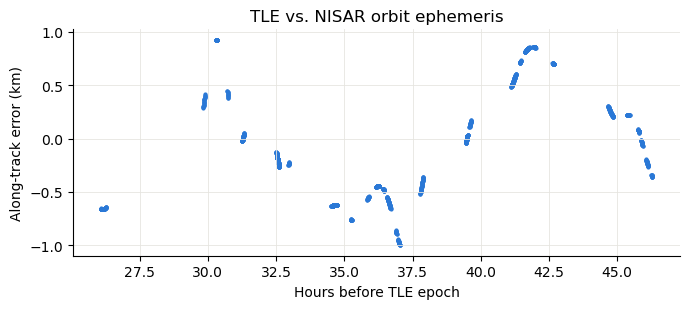

,n,median,p95 |x|,max |x|
along-track (km),1220.0,-0.166,0.860,1.002
"cross-track, right (km)",1220.0,0.062,0.256,0.334
radial (km),1220.0,-0.004,0.180,0.266


In [4]:
orbit_time = np.concatenate([m["orbit_time"] for m in meta])
orbit_position = np.concatenate([m["orbit_position"] for m in meta])
orbit_velocity = np.concatenate([m["orbit_velocity"] for m in meta])
p1, v1 = orbit.get_orbit_track(to_utc(orbit_time)).frame_xyz_and_velocity(itrs)
offset1 = np.array(p1.m).T - orbit_position
radial1 = normalize(orbit_position)
along1 = normalize(orbit_velocity - np.sum(orbit_velocity * radial1, axis=-1, keepdims=True) * radial1)
along1_km = np.sum(offset1 * along1, axis=-1) / 1e3
epoch = datetime(2026, 1, 1, tzinfo=timezone.utc) + timedelta(days=float(TLE[0][20:32]) - 1)
hours_before_epoch = (epoch - DAY).total_seconds() / 3600 - orbit_time / 3600
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.scatter(hours_before_epoch, along1_km, s=4, color=BLUE)
ax.set(xlabel="Hours before TLE epoch", ylabel="Along-track error (km)", title="TLE vs. NISAR orbit ephemeris")
fig.tight_layout()
plt.show()
pd.DataFrame(
    {
        "along-track (km)": summarize(along1_km),
        "cross-track, right (km)": summarize(np.sum(offset1 * np.cross(along1, radial1), axis=-1) / 1e3),
        "radial (km)": summarize(np.sum(offset1 * radial1, axis=-1) / 1e3),
    }
).T.round(3)

The TLE reproduces NISAR's orbit ephemeris to within about 1 km along track over the 26 to 46 hours before its epoch (0.9 km, 95th percentile), and to 0.3 km or better across track and radially.

## Test 2: Imaging Geometry

This test uses only the reference data. For each geolocation grid point, the line of sight runs from the spacecraft position at the point's zero-Doppler time (interpolated from the orbit state vectors) to the point. Three properties are measured:

* the **look direction**: the side of the ground track (left or right) on which the line of sight falls;
* the **imaging plane**: the angle between the line of sight and the plane perpendicular to the Earth-fixed velocity (zero by construction for zero-Doppler geometry) and to the inertial velocity;
* the **look angles**: the angles between the line of sight and the geodetic nadir at the near-range and far-range edges of each image, which correspond to TAT-C's roll angle and cross-track field of view. Incidence angles, measured from the vertical at the ground, are larger because of Earth's curvature.

In [5]:
rows2, side_all, plane_earth, plane_inertial = [], [], [], []
for m in meta:
    position, velocity = interpolate_orbit(m, m["time"])
    los = normalize(ecef(m["lon"], m["lat"]) - position[:, None])
    sub_lon, sub_lat, sub_alt = TO_GEODETIC.transform(*position.T)
    nadir = -up(sub_lon, sub_lat)
    left = normalize(np.cross(normalize(velocity), nadir))
    look = np.degrees(np.arccos(np.sum(los * nadir[:, None], axis=-1)))
    side_all.append(np.sign(np.sum(los * left[:, None], axis=-1)).ravel())
    plane_earth.append(np.degrees(np.arcsin(np.sum(los * normalize(velocity)[:, None], axis=-1))).ravel())
    plane_inertial.append(np.degrees(np.arcsin(np.sum(los * normalize(inertial_velocity(position, velocity))[:, None], axis=-1))).ravel())
    rows2.append(
        {
            "latitude": np.median(sub_lat),
            "altitude (km)": np.median(sub_alt) / 1e3,
            "near look (deg)": np.median(look[:, 0]),
            "far look (deg)": np.median(look[:, -1]),
            "near incidence (deg)": np.median(m["incidence"][:, 0]),
            "far incidence (deg)": np.median(m["incidence"][:, -1]),
        }
    )
geometry = pd.concat([sample[["granule", "mode", "direction"]], pd.DataFrame(rows2)], axis=1)
side_all, plane_earth, plane_inertial = map(np.concatenate, (side_all, plane_earth, plane_inertial))
# roll angle and cross-track field of view of each mode, from the median edge look angles
modes = geometry.groupby("mode")[["near look (deg)", "far look (deg)", "near incidence (deg)", "far incidence (deg)"]].median()
modes["roll (deg)"] = (modes["near look (deg)"] + modes["far look (deg)"]) / 2
modes["field of view (deg)"] = modes["far look (deg)"] - modes["near look (deg)"]
modes["products"] = catalog.groupby("mode").size()
print(
    pd.Series(
        {
            "lines of sight on the left (%)": 100 * np.mean(side_all > 0),
            "angle to Earth-fixed zero-Doppler plane, max |x| (deg)": np.abs(plane_earth).max(),
            "angle to inertial zero-Doppler plane, p95 |x| (deg)": np.percentile(np.abs(plane_inertial), 95),
            "near look angle, range within modes (deg)": (geometry.groupby("mode")["near look (deg)"].agg(np.ptp)).max(),
            "far look angle, range within modes (deg)": (geometry.groupby("mode")["far look (deg)"].agg(np.ptp)).max(),
        }
    ).round(5).to_string()
)
modes.round(2)

lines of sight on the left (%)                            100.00000
angle to Earth-fixed zero-Doppler plane, max |x| (deg)      0.00001
angle to inertial zero-Doppler plane, p95 |x| (deg)         2.40812
near look angle, range within modes (deg)                   0.57202
far look angle, range within modes (deg)                    0.56965


,near look (deg),far look (deg),near incidence (deg),far incidence (deg),roll (deg),field of view (deg),products
mode,,,,,,,
0005_NADV,30.05,41.02,34.06,47.21,35.53,10.97,33
0005_NASV,30.03,40.88,34.11,47.11,35.46,10.85,273
0500_SHNA,29.58,40.90,33.55,47.12,35.24,11.32,4
0505_SHSV,30.05,40.90,34.10,47.13,35.48,10.85,3
0505_SVSH,30.02,40.88,34.07,47.11,35.45,10.86,45
2000_DVNA,29.78,41.09,33.74,47.29,35.43,11.31,1
2005_DHDH,29.66,41.21,33.60,47.46,35.43,11.55,204
2005_DVDV,29.80,41.03,33.76,47.23,35.42,11.24,2
2005_QPDH,29.72,41.03,33.69,47.23,35.38,11.31,10


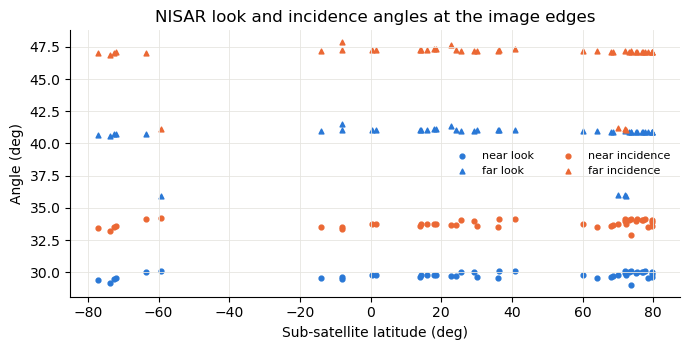

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for column, color in [("near look (deg)", BLUE), ("far look (deg)", BLUE), ("near incidence (deg)", ORANGE), ("far incidence (deg)", ORANGE)]:
    ax.scatter(geometry.latitude, geometry[column], s=12, color=color, marker="o" if "near" in column else "^", label=column.replace(" (deg)", ""))
ax.set(xlabel="Sub-satellite latitude (deg)", ylabel="Angle (deg)", title="NISAR look and incidence angles at the image edges")
ax.legend(frameon=False, fontsize=8, ncols=2)
fig.tight_layout()
plt.show()

All lines of sight fall to the left of the ground track and lie in the plane perpendicular to the Earth-fixed velocity, to within numerical precision: the images are in zero-Doppler geometry, which TAT-C's default Earth-fixed velocity frame reproduces. The inertial velocity frame would tilt the imaging plane by up to about 2.4 deg.

Most modes image look angles from about 29.5 to 30.0 deg at near range to 40.7 to 41.2 deg at far range (incidence angles of about 33.5 to 47.5 deg): a roll angle of about 35.3 deg and a cross-track field of view of about 11 deg. The 77 MHz mode (`7700`) images a narrower swath, from 29.9 to 36.0 deg (incidence 33.9 to 41.1 deg). Within a mode, the edge look angles vary by up to about 0.6 deg: NISAR's swath is set by a range window, so its look angles change with the spacecraft's altitude around the orbit, which a fixed roll angle and field of view do not follow.

## Test 3: Swath Edges

For each sampled product, a TAT-C `PointedInstrument` is defined with its mode's roll angle and cross-track field of view (Test 2). The rays at the near-range and far-range edges of its view (roll angles of the roll angle minus and plus half the field of view, which TAT-C's rigid rotation places exactly at the edge look angles) are projected to the ellipsoid at the zero-Doppler times of every fourth geolocation grid line and compared with the grid's near-range and far-range points, in both velocity frames. Residuals are decomposed along and to the right of the ground track (the horizontal direction of the reported Earth-fixed velocity) at each edge point.

In [7]:
rows3 = {}
for frame in [VelocityFrame.EARTH_FIXED, VelocityFrame.INERTIAL]:
    for edge, column in [("near", 0), ("far", -1)]:
        along_all, right_all = [], []
        for mode, m in zip(geometry["mode"], meta):
            look_angle = modes.loc[mode, f"{edge} look (deg)"]
            times = m["time"][::4]
            _, velocity = interpolate_orbit(m, times)
            ray = compute_projected_ray_position(orbit.get_orbit_track(to_utc(times)), 0, 0, look_angle, velocity_frame=frame)
            lon, lat = m["lon"][::4, column], m["lat"][::4, column]
            along, right = along_right(lon, lat, ecef(ray.longitude.degrees, ray.latitude.degrees) - ecef(lon, lat), velocity)
            along_all.append(along)
            right_all.append(right)
        rows3[(frame.value, edge, "along")] = summarize(np.concatenate(along_all))
        rows3[(frame.value, edge, "right")] = summarize(np.concatenate(right_all))
pd.DataFrame(rows3).T.round(2)

n  median  p95 |x|  max |x|
earth_fixed near along  4815.0    0.06     1.92     2.22
                 right  4815.0    0.07     4.68    10.37
            far  along  4815.0    0.07     1.95     2.27
                 right  4815.0    0.06     6.85     8.75
inertial    near along  4815.0   -4.72    30.58    31.65
                 right  4815.0    0.35     4.74    10.31
            far  along  4815.0   -7.53    47.61    48.94
                 right  4815.0    0.41     6.47    10.34

With the Earth-fixed velocity frame, TAT-C's view edges match the image edges to within about 2 km along track and 5 to 7 km across track (95th percentile). The cross-track residual reflects the variation of the look angles within each mode (Test 2). The inertial velocity frame displaces the edges by 30 to 50 km along track (95th percentile), the rotation of the zero-Doppler plane over the slant range to the swath.

## Test 4: Frame Footprints

For every RSLC product acquired on the day, TAT-C's footprints from `compute_ground_track`, with its mode's roll angle and field of view, at time steps of about 5 s between the product's zero-Doppler start and end times (with the along-track field of view tailored to the time step, as in the imager notebooks), are merged and compared with the product's bounding polygon, in an azimuthal equidistant projection centered on the product.

In [8]:
TIME_STEP = 5  # s
ground_speed = 2 * np.pi * 6371.0088e3 / (86400 / float(TLE[1][52:63]))
altitude = float(np.median(geometry["altitude (km)"])) * 1e3


def nisar_view(mode, time_step=TIME_STEP, velocity_frame=VelocityFrame.EARTH_FIXED):
    """Rectangular, left-looking view of a NISAR mode, with the along-track field of view tailored to a time step (s)."""
    return PointedInstrument(
        name="NISAR L-SAR",
        field_of_regard=2 * (modes["far look (deg)"].max() + 1),
        cross_track_field_of_view=modes.loc[mode, "field of view (deg)"],
        along_track_field_of_view=np.degrees(2 * np.arctan(ground_speed * time_step / 2 / altitude)),
        roll_angle=modes.loc[mode, "roll (deg)"],
        is_rectangular=True,
        velocity_frame=velocity_frame,
    )


def unwrap(geometry):
    """Shift longitudes of a polygon that crosses the antimeridian to be continuous."""
    lon = np.array(geometry.exterior.coords)[:, 0]
    if lon.max() - lon.min() > 180:
        return shapely.ops.transform(lambda x, y, z=None: (np.where(np.asarray(x) < 0, np.asarray(x) + 360, x), y), geometry)
    return geometry


def footprint_row(product):
    start, end = pd.Timestamp(product.zero_doppler_start, tz="UTC"), pd.Timestamp(product.zero_doppler_end, tz="UTC")
    n = max(1, int(round((end - start).total_seconds() / TIME_STEP)))
    step = (end - start) / n
    times = [(start + step * (i + 0.5)).floor("us").to_pydatetime() for i in range(n)]
    satellite = nisar.model_copy(update={"instruments": [nisar_view(product["mode"], step.total_seconds())]})
    predicted = compute_ground_track(satellite, times).geometry.iloc[0]
    observed = unwrap(shapely.force_2d(shapely.from_wkt(product.polygon)))
    center = observed.centroid
    project = Transformer.from_crs("EPSG:4326", f"+proj=aeqd +lat_0={center.y} +lon_0={center.x} +units=m", always_xy=True).transform
    a, b = transform_geometry(project, observed).buffer(0), transform_geometry(project, predicted).buffer(0)
    return {
        "granule": product.granule,
        "observed (km^2)": a.area / 1e6,
        "TAT-C (km^2)": b.area / 1e6,
        "IoU": a.intersection(b).area / a.union(b).area,
        "latitude": center.y,
    }


footprints = pd.DataFrame([footprint_row(product) for _, product in catalog.iterrows()]).merge(catalog[["granule", "mode", "direction", "coverage"]])
pd.concat(
    [
        footprints[["IoU"]].describe(percentiles=[0.05, 0.5]).T.assign(group="all"),
        footprints.groupby("coverage").IoU.describe(percentiles=[0.05, 0.5]).assign(group="coverage"),
        footprints.groupby("mode").IoU.describe(percentiles=[0.05, 0.5]).assign(group="mode"),
    ]
).round(3)

,count,mean,std,min,5%,50%,max,group
IoU,855.0,0.931,0.041,0.713,0.851,0.944,0.970,all
full,596.0,0.948,0.014,0.880,0.922,0.951,0.970,coverage
partial,259.0,0.890,0.052,0.713,0.785,0.906,0.961,coverage
0005_NADV,33.0,0.944,0.027,0.879,0.884,0.958,0.965,mode
0005_NASV,273.0,0.932,0.038,0.722,0.870,0.944,0.970,mode
0500_SHNA,4.0,0.952,0.016,0.928,0.933,0.960,0.963,mode
0505_SHSV,3.0,0.964,0.003,0.962,0.962,0.963,0.968,mode
0505_SVSH,45.0,0.946,0.033,0.793,0.878,0.958,0.968,mode
2000_DVNA,1.0,0.965,NaN,0.965,0.965,0.965,0.965,mode
2005_DHDH,204.0,0.922,0.039,0.713,0.847,0.934,0.961,mode


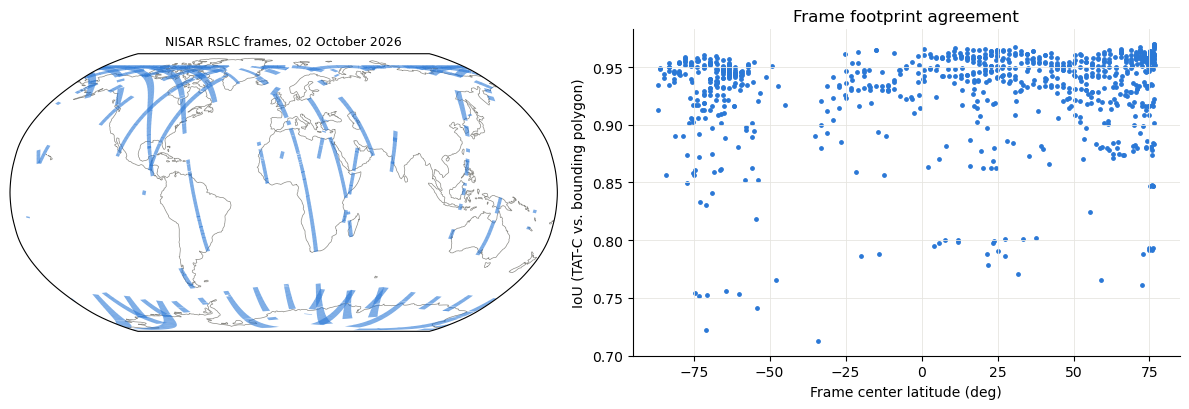

In [9]:
fig = plt.figure(figsize=(12, 4.2))
ax = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())
ax.set_global()
ax.coastlines(color=GRAY, linewidth=0.5)
for polygon in catalog.polygon:
    # split footprints that cross the antimeridian for plotting
    footprint = unwrap(shapely.force_2d(shapely.from_wkt(polygon)))
    parts = [footprint.intersection(shapely.box(-180, -90, 180, 90)), shapely.affinity.translate(footprint.intersection(shapely.box(180, -90, 540, 90)), -360)]
    ax.add_geometries([part for part in parts if not part.is_empty], crs=ccrs.PlateCarree(), facecolor=BLUE, edgecolor="none", alpha=0.6)
ax.set_title(f"NISAR RSLC frames, {DAY:%d %B %Y}", fontsize=9)
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(footprints.latitude, footprints.IoU, s=6, color=BLUE)
ax2.set(xlabel="Frame center latitude (deg)", ylabel="IoU (TAT-C vs. bounding polygon)", title="Frame footprint agreement")
fig.tight_layout()
plt.show()

TAT-C reproduces the footprints of full frames with an intersection over union (IoU) of 0.95 (median; 0.92 at the 5th percentile) and of all frames with 0.94, for every mode including the narrow 77 MHz mode. Partial frames agree less well (0.91), because their bounding polygons outline only the part of the frame with valid data. The remaining differences reflect the look angle variation within modes (Test 3) and terrain: bounding polygons are at the terrain height, whereas TAT-C's footprints are on the ellipsoid.

## Test 5: Observation Times

Each geolocation grid point is a ground point with a known zero-Doppler time: the time at which NISAR imaged it. For interior grid points of each sampled product (excluding the outer 10% of the slant range extent and the first and last grid lines), `collect_observations` is run over a window of 10 minutes around the zero-Doppler time with the product's mode's `PointedInstrument` in each velocity frame, and the observation epoch nearest the zero-Doppler time is compared with it.

In [10]:
rows5 = {}
for frame in [VelocityFrame.EARTH_FIXED, VelocityFrame.INERTIAL]:
    differences, missed = [], 0
    for mode, m in zip(geometry["mode"], meta):
        satellite = nisar.model_copy(update={"instruments": [nisar_view(mode, velocity_frame=frame)]})
        for i in np.linspace(1, len(m["time"]) - 2, 3).astype(int):
            for j in (np.linspace(0.1, 0.9, 5) * (len(m["slant_range"]) - 1)).round().astype(int):
                point = Point(id=0, latitude=float(m["lat"][i, j]), longitude=float(m["lon"][i, j]))
                truth = DAY + timedelta(seconds=float(m["time"][i]))
                observations = collect_observations(point, satellite, truth - timedelta(minutes=5), truth + timedelta(minutes=5))
                if observations.empty:
                    missed += 1
                    continue
                seconds = (observations.epoch - pd.Timestamp(truth)).dt.total_seconds().to_numpy()
                differences.append(seconds[np.argmin(np.abs(seconds))])
    rows5[frame.value] = pd.concat([pd.Series({"points": len(differences) + missed, "missed": missed}), summarize(differences).drop("n")])
pd.DataFrame(rows5).T.rename(columns={"median": "time, median (s)", "p95 |x|": "time, p95 |x| (s)", "max |x|": "time, max |x| (s)"}).round(3)

,points,missed,"time, median (s)","time, p95 |x| (s)","time, max |x| (s)"
earth_fixed,660.0,0.0,-0.001,0.301,0.337
inertial,660.0,0.0,0.658,6.368,7.150


With the Earth-fixed velocity frame, `collect_observations` reports each point's observation epoch within 0.3 s of its zero-Doppler time (95th percentile), about 2 km of travel along the orbit, and observes every point. The inertial velocity frame shifts the epochs by up to about 7 s.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (CelesTrak TLE vs. orbit ephemeris) | 0.9 km along track (95th percentile) 26 to 46 hours before the TLE epoch |
| 2. Imaging geometry | left-looking; images in the plane perpendicular to the *Earth-fixed* velocity (inertial: up to 2.4 deg); roll about 35.3 deg and field of view about 11 deg (77 MHz mode: 32.9 and 6.1 deg); look angles vary by up to 0.6 deg within a mode |
| 3. Swath edges | 2 km along track and 5 to 7 km across track (95th percentile) with the Earth-fixed frame; 30 to 50 km along track with the inertial frame |
| 4. Frame footprints (`compute_ground_track`) | IoU 0.95 for full frames, 0.94 for all 855 frames (median) |
| 5. Observation times (`collect_observations`) | 0.3 s (95th percentile) with the Earth-fixed frame; up to 7 s with the inertial frame |

**Velocity frame.** A SAR forms its images in zero-Doppler geometry, in the plane perpendicular to the Earth-fixed velocity, whatever the attitude of the spacecraft. TAT-C's default `VelocityFrame.EARTH_FIXED` reproduces this, while `VelocityFrame.INERTIAL` (appropriate for imagers that scan without yaw steering, such as those of NOAA-20) would displace NISAR's swath edges by up to 50 km along track and its observation times by up to 7 s.

**Roll angle and field of view.** A left-looking `PointedInstrument` with a positive roll angle, rotated rigidly so that its edge rays lie at the image's edge look angles, reproduces NISAR's swath to within a few kilometers. Parameters should be chosen per mode: most modes share a swath of about 240 km, but the 77 MHz mode images a narrower swath. Because NISAR fixes the slant range of its swath rather than its look angles, the look angles at the swath edges vary by up to 0.6 deg around the orbit, which a fixed roll angle and field of view do not follow; the resulting edge errors of about 5 km are small compared with the swath.

**Along-track field of view.** As for the imagers, an along-track field of view tailored to the analysis time step lets consecutive TAT-C views tile the swath, and `collect_observations` reports the time at which the view sweeps over a point, matching NISAR's zero-Doppler times.